In [8]:
import pandas as pd

df = pd.read_csv('C:/PROJECTS/HOSPITAL PATIENT ANALYSIS/healthcare_dataset.csv')

print("Total patients:",len(df))
print("columns:", df.columns.tolist())
print("\nFirst 3 rows:")
df.head(3)

Total patients: 55500
columns: ['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition', 'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider', 'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date', 'Medication', 'Test Results']

First 3 rows:


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal


In [4]:
import os

# List all files in PROJECTS folder
files = os.listdir('C:/PROJECTS/')
for f in files:
    print(f)
    

.ipynb_checkpoints
DELOITTE data analytics job simulation
HOSPITAL PATIENT ANALYSIS
HR ANALYTICS DASHBOARD
METRO CROWD MANAGMENT
nodejs
Parking-project
SMART CAFE.zip
Untitled.ipynb
ZOMATO BENGALURU RESTRAUNT ANALYSIS


In [5]:
import os

# Look inside the hospital folder
folder = 'C:/PROJECTS/HOSPITAL PATIENT ANALYSIS/'
files = os.listdir(folder)
for f in files:
    print(f)
    

.ipynb_checkpoints
healthcare_dataset.csv
Untitled.ipynb


In [9]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicates:", df.duplicated().sum())

print("\nBasic stats:")
df.describe()

Missing values:
Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

Duplicates: 534

Basic stats:


,Age,Billing Amount,Room Number
count,55500.000000,55500.000000,55500.000000
mean,51.539459,25539.316097,301.134829
std,19.602454,14211.454431,115.243069
min,13.000000,-2008.492140,101.000000
25%,35.000000,13241.224652,202.000000
50%,52.000000,25538.069376,302.000000
75%,68.000000,37820.508436,401.000000
max,89.000000,52764.276736,500.000000


In [10]:
# Step 1: Remove duplicates
df = df.drop_duplicates()
print("After removing duplicates:", len(df))

# Step 2: Fix negative billing amounts
df = df[df['Billing Amount'] > 0]
print("After removing negative billing:", len(df))

# Step 3: Convert dates to proper date format
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])

# Step 4: Calculate Length of Stay (days)
df['Length of Stay'] = (df['Discharge Date'] - 
                        df['Date of Admission']).dt.days

print("\nLength of Stay stats:")
print(df['Length of Stay'].describe())

# Step 5: Save clean file
df.to_csv('C:/PROJECTS/HOSPITAL PATIENT ANALYSIS/hospital_clean.csv', 
          index=False)
print("\n✅ Clean file saved! Rows:", len(df))

After removing duplicates: 54966
After removing negative billing: 54860

Length of Stay stats:
count    54860.000000
mean        15.498815
std          8.661357
min          1.000000
25%          8.000000
50%         15.000000
75%         23.000000
max         30.000000
Name: Length of Stay, dtype: float64

✅ Clean file saved! Rows: 54860


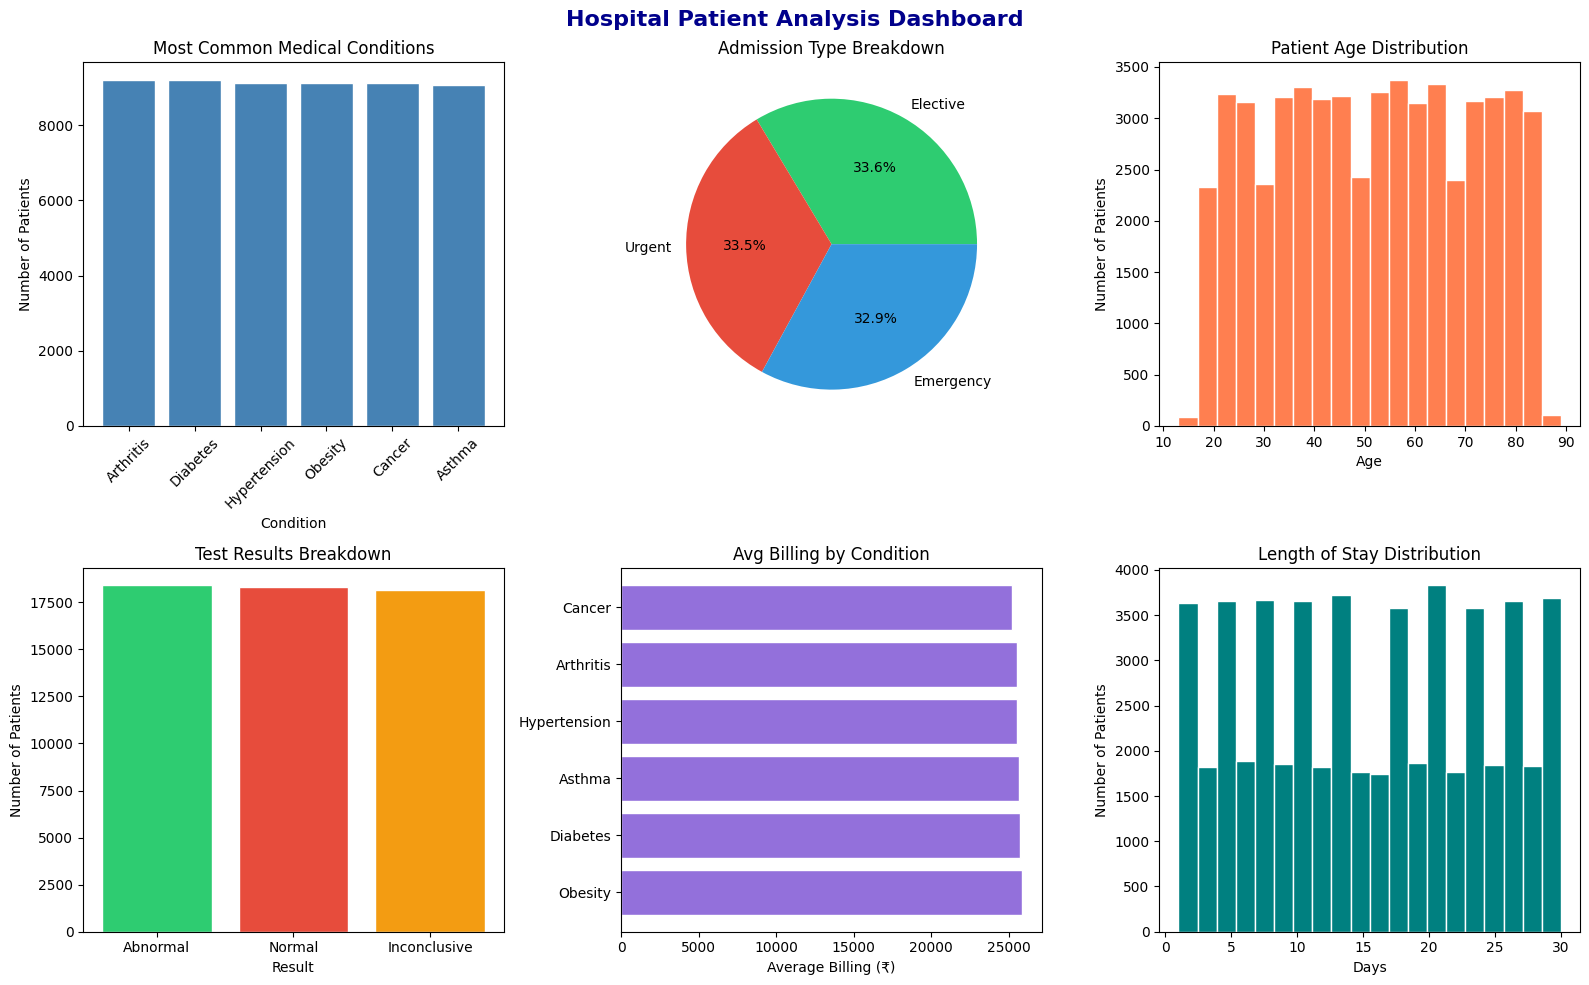

✅ Charts saved!


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Hospital Patient Analysis Dashboard', 
             fontsize=16, fontweight='bold', color='darkblue')

# Chart 1 — Most common medical conditions
condition_counts = df['Medical Condition'].value_counts()
axes[0,0].bar(condition_counts.index, condition_counts.values,
              color='steelblue', edgecolor='white')
axes[0,0].set_title('Most Common Medical Conditions')
axes[0,0].set_xlabel('Condition')
axes[0,0].set_ylabel('Number of Patients')
axes[0,0].tick_params(axis='x', rotation=45)

# Chart 2 — Admission type breakdown
admission_counts = df['Admission Type'].value_counts()
axes[0,1].pie(admission_counts.values,
              labels=admission_counts.index,
              autopct='%1.1f%%',
              colors=['#2ecc71','#e74c3c','#3498db'])
axes[0,1].set_title('Admission Type Breakdown')

# Chart 3 — Age distribution
axes[0,2].hist(df['Age'], bins=20, 
               color='coral', edgecolor='white')
axes[0,2].set_title('Patient Age Distribution')
axes[0,2].set_xlabel('Age')
axes[0,2].set_ylabel('Number of Patients')

# Chart 4 — Test results breakdown
test_counts = df['Test Results'].value_counts()
axes[1,0].bar(test_counts.index, test_counts.values,
              color=['#2ecc71','#e74c3c','#f39c12'],
              edgecolor='white')
axes[1,0].set_title('Test Results Breakdown')
axes[1,0].set_xlabel('Result')
axes[1,0].set_ylabel('Number of Patients')

# Chart 5 — Avg billing by medical condition
avg_billing = df.groupby('Medical Condition')['Billing Amount'].mean().sort_values(ascending=False)
axes[1,1].barh(avg_billing.index, avg_billing.values,
               color='mediumpurple', edgecolor='white')
axes[1,1].set_title('Avg Billing by Condition')
axes[1,1].set_xlabel('Average Billing (₹)')

# Chart 6 — Length of stay distribution
axes[1,2].hist(df['Length of Stay'], bins=20,
               color='teal', edgecolor='white')
axes[1,2].set_title('Length of Stay Distribution')
axes[1,2].set_xlabel('Days')
axes[1,2].set_ylabel('Number of Patients')

plt.tight_layout()
plt.savefig('C:/PROJECTS/HOSPITAL PATIENT ANALYSIS/charts.png', 
            dpi=150)
plt.show()
print("✅ Charts saved!")

In [12]:
import sqlite3

# Load clean data into SQL database
conn = sqlite3.connect(
  'C:/PROJECTS/HOSPITAL PATIENT ANALYSIS/hospital.db')
df.to_sql('patients', conn, 
          if_exists='replace', index=False)
print("✅ Data loaded into SQL!")

# Query 1 — Most common conditions
q1 = pd.read_sql_query("""
    SELECT "Medical Condition",
           COUNT(*) AS total_patients,
           ROUND(AVG("Billing Amount"), 2) AS avg_billing,
           ROUND(AVG("Length of Stay"), 1) AS avg_stay_days
    FROM patients
    GROUP BY "Medical Condition"
    ORDER BY total_patients DESC
""", conn)
print("\n📊 Conditions Analysis:")
print(q1)

# Query 2 — Admission type analysis
q2 = pd.read_sql_query("""
    SELECT "Admission Type",
           COUNT(*) AS total,
           ROUND(AVG("Billing Amount"), 2) AS avg_billing,
           ROUND(AVG("Length of Stay"), 1) AS avg_stay
    FROM patients
    GROUP BY "Admission Type"
    ORDER BY avg_billing DESC
""", conn)
print("\n🏥 Admission Type Analysis:")
print(q2)

# Query 3 — Age group analysis
q3 = pd.read_sql_query("""
    SELECT
      CASE
        WHEN Age < 20 THEN 'Teen (13-19)'
        WHEN Age < 40 THEN 'Young (20-39)'
        WHEN Age < 60 THEN 'Middle (40-59)'
        WHEN Age < 80 THEN 'Senior (60-79)'
        ELSE 'Elderly (80+)'
      END AS age_group,
      COUNT(*) AS patients,
      ROUND(AVG("Billing Amount"), 2) AS avg_billing,
      ROUND(AVG("Length of Stay"), 1) AS avg_stay
    FROM patients
    GROUP BY age_group
    ORDER BY patients DESC
""", conn)
print("\n👥 Age Group Analysis:")
print(q3)

# Query 4 — Test results by condition
q4 = pd.read_sql_query("""
    SELECT "Medical Condition",
           "Test Results",
           COUNT(*) AS count
    FROM patients
    GROUP BY "Medical Condition", "Test Results"
    ORDER BY "Medical Condition", count DESC
""", conn)
print("\n🧪 Test Results by Condition:")
print(q4)

conn.close()
print("\n✅ All SQL queries done!")

✅ Data loaded into SQL!

📊 Conditions Analysis:
  Medical Condition  total_patients  avg_billing  avg_stay_days
0         Arthritis            9207     25542.90           15.5
1          Diabetes            9197     25714.33           15.4
2      Hypertension            9131     25559.84           15.4
3           Obesity            9127     25859.22           15.4
4            Cancer            9121     25205.92           15.5
5            Asthma            9077     25685.39           15.7

🏥 Admission Type Analysis:
  Admission Type  total  avg_billing  avg_stay
0       Elective  18437     25663.34      15.5
1         Urgent  18353     25568.44      15.4
2      Emergency  18070     25551.13      15.6

👥 Age Group Analysis:
        age_group  patients  avg_billing  avg_stay
0  Middle (40-59)     16275     25546.81      15.5
1  Senior (60-79)     16070     25628.55      15.6
2   Young (20-39)     16003     25602.78      15.4
3   Elderly (80+)      4838     25347.96      15.4
4    Teen 

In [1]:
import pandas as pd
import sqlite3

# Load clean data again
df = pd.read_csv('C:/PROJECTS/HOSPITAL PATIENT ANALYSIS/hospital_clean.csv')

conn = sqlite3.connect(
  'C:/PROJECTS/HOSPITAL PATIENT ANALYSIS/hospital.db')

df.to_sql('patients', conn, if_exists='replace', index=False)

# Save Query 1
q1 = pd.read_sql_query("""
    SELECT "Medical Condition",
           COUNT(*) AS total_patients,
           ROUND(AVG("Billing Amount"),2) AS avg_billing,
           ROUND(AVG("Length of Stay"),1) AS avg_stay_days
    FROM patients
    GROUP BY "Medical Condition"
    ORDER BY total_patients DESC
""", conn)
q1.to_csv('C:/PROJECTS/HOSPITAL PATIENT ANALYSIS/q1_conditions.csv', index=False)

# Save Query 2
q2 = pd.read_sql_query("""
    SELECT "Admission Type",
           COUNT(*) AS total,
           ROUND(AVG("Billing Amount"),2) AS avg_billing,
           ROUND(AVG("Length of Stay"),1) AS avg_stay
    FROM patients
    GROUP BY "Admission Type"
    ORDER BY avg_billing DESC
""", conn)
q2.to_csv('C:/PROJECTS/HOSPITAL PATIENT ANALYSIS/q2_admission.csv', index=False)

# Save Query 3
q3 = pd.read_sql_query("""
    SELECT
      CASE
        WHEN Age < 20 THEN 'Teen (13-19)'
        WHEN Age < 40 THEN 'Young (20-39)'
        WHEN Age < 60 THEN 'Middle (40-59)'
        WHEN Age < 80 THEN 'Senior (60-79)'
        ELSE 'Elderly (80+)'
      END AS age_group,
      COUNT(*) AS patients,
      ROUND(AVG("Billing Amount"),2) AS avg_billing,
      ROUND(AVG("Length of Stay"),1) AS avg_stay
    FROM patients
    GROUP BY age_group
    ORDER BY patients DESC
""", conn)
q3.to_csv('C:/PROJECTS/HOSPITAL PATIENT ANALYSIS/q3_age_groups.csv', index=False)

conn.close()
print("✅ All CSV files saved!")

✅ All CSV files saved!
